**Deskripsi Perusahaan**
Sebuah perusahaan e-commerce berskala nasional bernama “Shopshop” menjual berbagai produk kebutuhan sehari-hari melalui aplikasi dan website. Perusahaan memiliki ribuan pelanggan aktif dengan beragam profil: umur, lokasi, preferensi device, metode pembayaran, dan kebiasaan belanja.

**Konteks Bisnis**
Dalam industri e-commerce, persaingan sangat ketat. Biaya untuk mendapatkan pelanggan baru (customer acquisition) biasanya jauh lebih mahal daripada mempertahankan pelanggan lama (customer retention). Karena itu, perusahaan ingin memahami pola perilaku pelanggan yang berhenti berbelanja (churn) agar dapat meningkatkan strategi retensi.



**problem statemnet :**

Tingkat customer churn mulai meningkat, terutama di segmen pelanggan tertentu.
Perusahaan perlu mengetahui faktor-faktor utama yang mempengaruhi churn.
Tujuan akhirnya adalah membantu tim manajemen membuat strategi untuk mengurangi churn dan meningkatkan loyalitas pelanggan.

#Data Understanding


* **CustomerID** → ID unik pelanggan
* **Churn** → Status churn (apakah pelanggan berhenti menggunakan layanan)
* **Tenure** → Lama pelanggan bergabung dengan perusahaan
* **PreferredLoginDevice** → Perangkat login yang paling sering digunakan pelanggan
* **CityTier** → Tingkat kota (kategori kota tempat pelanggan berada)
* **WarehouseToHome** → Jarak dari gudang ke rumah pelanggan
* **PreferredPaymentMode** → Metode pembayaran yang paling sering digunakan pelanggan
* **Gender** → Jenis kelamin pelanggan
* **HourSpendOnApp** → Jumlah jam yang dihabiskan di aplikasi atau website
* **NumberOfDeviceRegistered** → Jumlah perangkat yang terdaftar pada akun pelanggan
* **PreferedOrderCat** → Kategori pesanan yang paling sering dipesan pelanggan di bulan terakhir
* **SatisfactionScore** → Skor kepuasan pelanggan terhadap layanan
* **MaritalStatus** → Status pernikahan pelanggan
* **NumberOfAddress** → Jumlah alamat yang ditambahkan oleh pelanggan
* **Complain** → Apakah ada keluhan yang diajukan dalam bulan terakhir
* **OrderAmountHikeFromlastYear** → Persentase peningkatan jumlah pesanan dibandingkan tahun lalu
* **CouponUsed** → Jumlah kupon yang digunakan dalam bulan terakhir
* **OrderCount** → Jumlah pesanan yang dilakukan dalam bulan terakhir
* **DaySinceLastOrder** → Jumlah hari sejak terakhir kali pelanggan melakukan pesanan
* **CashbackAmount** → Rata-rata jumlah cashback yang diterima dalam bulan terakhir

In [1]:
import pandas as pd
import numpy as np

In [2]:
import pandas as pd

url = "https://github.com/hanihandayani2002/Portfolio/raw/main/BDA_Portfolio/E%20Commerce%20Dataset.xlsx"
df_churn = pd.read_excel(url, sheet_name="E Comm", engine="openpyxl")
df_churn.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [3]:
df_churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

In [4]:
df_churn.isna().sum()

,0
CustomerID,0
Churn,0
Tenure,264
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,251
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,255
NumberOfDeviceRegistered,0


In [5]:
df_churn.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


1. Churn Rate

   - Sekitar 16,8% pelanggan churn, sisanya masih aktif-> Artinya mayoritas pelanggan masih bertahan, tapi churn tetap signifikan.

2. Tenure (lama berlangganan)
   - Rata-rata pelanggan bertahan 10 bulan, dengan mayoritas berada di bawah 1,5 tahun.

   - Ada pelanggan sangat loyal (hingga 61 bulan), tapi jumlahnya sedikit.

3. Demografi Kota (City Tier)

   - Mayoritas pengguna berasal dari kota tier 1 & 2, rata-rata 1,65.

   - Pengguna di kota tier 3 relatif lebih sedikit.

4. Perilaku Penggunaan Aplikasi

   - Rata-rata waktu di aplikasi 2,9 jam/hari.

   - Pengguna rata-rata mendaftarkan 3–4 perangkat.

   - Tingkat kepuasan berada di angka 3,06 (netral) → belum terlalu puas.

5. Keluhan (Complain)

   - Sekitar 28% pelanggan pernah komplain, sisanya tidak -> Bisa jadi salah satu faktor yang memicu churn.

6. Pola Belanja

   - Rata-rata pelanggan melakukan 3 pesanan dan menggunakan sekitar 1–2 kupon.

   - Ada pelanggan yang sangat aktif (hingga 16 order).

   - Rata-rata peningkatan order year-on-year = 15,7%, cukup sehat.

7. Cashback

   - Rata-rata cashback diterima sekitar 177, dengan maksimum mencapai 325.
   - Cashback cukup besar, mungkin jadi salah satu strategi retensi.

8. Frekuensi Order
   - Rata-rata jarak antar order 4–5 hari.

   - Ada pelanggan yang sangat jarang (hingga 46 hari).



- Mayoritas perangkat login yang paling sering digunakan pelanggan adalah Mobile Phone
- pembayaran dilakukan menggunakan debit card
- Male paling banyak membeli produk
- barang yang paling banyak dibeli adalah Laptop & Accessory
- yang membeli barang mayoritas yang sudah berkeluarga (married)

#Data Cleaning

### Handling Missing Value

cek pola missing value, apakah ada berhubungan satu sama lain

In [6]:
#cek korelasi antar kolom yang NaN
df_churn.isna().corr()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
CustomerID,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Churn,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure,NaN,NaN,1.000000,NaN,NaN,-0.047914,NaN,NaN,-0.048312,NaN,NaN,NaN,NaN,NaN,NaN,-0.049296,-0.048411,-0.048609,-0.053268,NaN
PreferredLoginDevice,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CityTier,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
WarehouseToHome,NaN,NaN,-0.047914,NaN,NaN,1.000000,NaN,NaN,-0.047051,NaN,NaN,NaN,NaN,NaN,NaN,-0.048009,-0.047147,-0.047340,-0.051877,NaN
PreferredPaymentMode,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
HourSpendOnApp,NaN,NaN,-0.048312,NaN,NaN,-0.047051,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,-0.048408,-0.047539,-0.047733,-0.052308,NaN
NumberOfDeviceRegistered,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Proporsi missing value relatif kecil (~5%), dan tidak ada keterkaitan antar kolom yang signifikan. maka kita bisa isi nilai kosong diimputasi menggunakan median per kolom.

pada tahap data cleaning kita akan melakukan fillna pada missing value dengan mengisi nilai median disetiap kolom yang missing

In [7]:
#isi tenure dengan nilai median
df_churn["Tenure"].fillna(df_churn["Tenure"].median(), inplace=True)
df_churn["DaySinceLastOrder"].fillna(df_churn["DaySinceLastOrder"].median(), inplace=True)
df_churn['OrderAmountHikeFromlastYear'].fillna(df_churn['OrderAmountHikeFromlastYear'].median(), inplace=True)
df_churn['CouponUsed'].fillna(df_churn['CouponUsed'].median(), inplace=True) # tetap isi median karena jika 0 belum tentu mereka sama sekali tidak menggunakan kupon bisa saja tidak tercatat atau sistem eror jadi better median agar aman datanya
df_churn['OrderCount'].fillna(df_churn['OrderCount'].median(), inplace=True) #coupun
df_churn['CashbackAmount'].fillna(df_churn['CashbackAmount'].median(), inplace=True)
df_churn['WarehouseToHome'].fillna(df_churn['WarehouseToHome'].median(), inplace=True)
df_churn['HourSpendOnApp'].fillna(df_churn['HourSpendOnApp'].median(), inplace=True)

/tmp/ipython-input-395640867.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_churn["Tenure"].fillna(df_churn["Tenure"].median(), inplace=True)
/tmp/ipython-input-395640867.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpl

Saya memilih mengisi missing value dengan median karena lebih aman dan netral. Jika saya mengisi dengan 0, maka saya berasumsi pelanggan sama sekali tidak melakukan aktivitas, padahal kemungkinan besar datanya hanya tidak tercatat. Median menjaga distribusi tetap representatif, menghindari bias, dan proporsi missing yang kecil membuat imputasi ini valid.

In [8]:
df_churn.isna().sum()

,0
CustomerID,0
Churn,0
Tenure,0
PreferredLoginDevice,0
CityTier,0
WarehouseToHome,0
PreferredPaymentMode,0
Gender,0
HourSpendOnApp,0
NumberOfDeviceRegistered,0


setelah dilakukan fillna, data sudah bersih dan bisa dilakukan analisis lebih mnedalam

In [9]:
df_churn.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,9.0,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,9.0,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,3.0,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


dari kolom ini kita bisa lihat ada kategori yang sama seperti cash on delivery dan COD ini sebenarnya kategori yang sama tapi didalam data ini dibuat terpisah, jadi kita akan gabung menjadi satu kategori agar bisa di analisis lebih jelas

In [10]:
#predereedpaymentmode cash on delviery gabung menjadi satu kategori menjadi COD
df_churn['PreferredPaymentMode'] = df_churn['PreferredPaymentMode'].replace('COD','Cash on Delivery')

In [11]:
#cek cash on delivery apakah masih ada di kolom paymentmode
df_churn[df_churn['PreferredPaymentMode']=='Cash on Delivery']

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
6,50007,1,9.0,Phone,3,11.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,2,Divorced,4,0,14.0,0.0,1.0,0.0,120.86
10,50011,1,4.0,Mobile Phone,1,18.0,Cash on Delivery,Female,2.0,3,Others,3,Divorced,2,0,15.0,9.0,15.0,8.0,295.45
12,50013,1,0.0,Phone,1,11.0,Cash on Delivery,Male,2.0,3,Mobile,3,Single,2,1,13.0,2.0,2.0,2.0,134.41
30,50031,0,2.0,Computer,1,6.0,Cash on Delivery,Male,2.0,3,Laptop & Accessory,3,Divorced,2,0,13.0,0.0,1.0,9.0,143.19
45,50046,0,0.0,Phone,1,23.0,Cash on Delivery,Male,3.0,3,Mobile,4,Divorced,1,1,16.0,1.0,1.0,1.0,130.58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5530,55531,0,21.0,Computer,1,21.0,Cash on Delivery,Male,4.0,4,Laptop & Accessory,4,Married,10,0,19.0,1.0,2.0,8.0,179.67
5550,55551,1,1.0,Phone,1,24.0,Cash on Delivery,Male,3.0,5,Mobile Phone,1,Married,7,0,13.0,2.0,2.0,4.0,148.67
5569,55570,0,14.0,Computer,1,18.0,Cash on Delivery,Female,4.0,4,Laptop & Accessory,3,Married,3,0,12.0,8.0,10.0,5.0,188.23
5604,55605,1,20.0,Phone,1,14.0,Cash on Delivery,Male,4.0,4,Mobile Phone,3,Married,10,0,12.0,7.0,10.0,9.0,148.39


#Exploratory Data Analysis (EDA)

## Proporsi Churn

/tmp/ipython-input-1621859790.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_churn, x='Churn', palette="Set2")


<Axes: xlabel='Churn', ylabel='count'>

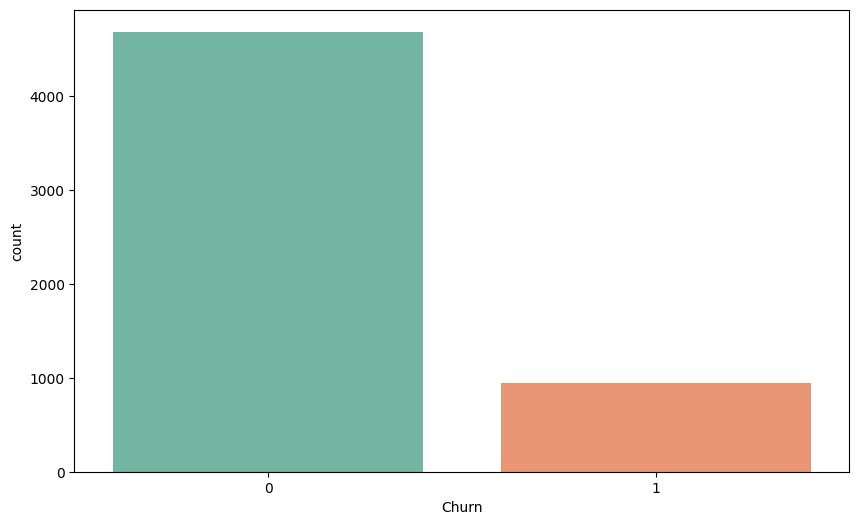

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
df_churn['Churn'].value_counts(normalize=True) * 100
sns.countplot(data=df_churn, x='Churn', palette="Set2")

#Korelasi Antar Kolom dengan Churn

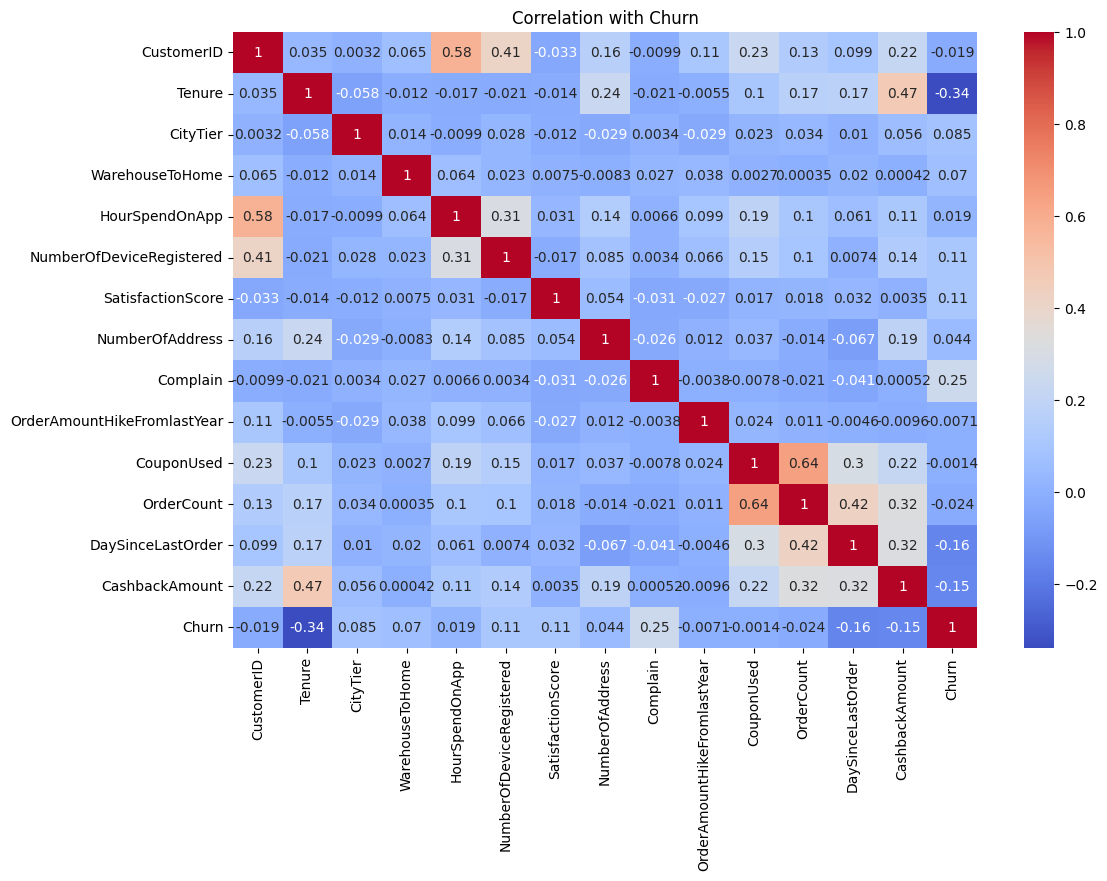

In [15]:
# Buat daftar kolom numerik
num_cols = df_churn.select_dtypes(include=['int64','float64']).columns.tolist()

# Pastikan 'Churn' tidak double, jadi bisa drop dulu
if "Churn" in num_cols:
    num_cols.remove("Churn")

# Hitung korelasi
corr = df_churn[num_cols + ["Churn"]].corr()

# Visualisasi heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation with Churn")
plt.show()

Faktor utama **churn ada pada Tenure (pelanggan baru lebih mudah churn) dan aktivitas belanja (OrderCount + Cashback).**

Waktu di aplikasi (HourSpendOnApp) dan kenaikan belanja tahunan (OrderAmountHikeFromLastYear) tidak terlalu mempengaruhi churn.

In [18]:
df_churn['Churn']

,Churn
0,1
1,1
2,1
3,1
4,1
...,...
5625,0
5626,0
5627,0
5628,0


In [19]:
#hitung churn rate customer yang churn==1 dibagi dengan total customer
churn_rate = (df_churn.groupby("Churn")["Churn"].count()/df_churn["Churn"].count())*100
churn_rate

,Churn
Churn,
0,83.161634
1,16.838366


## Tenure vs Churn

/tmp/ipython-input-614087366.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn, x='Churn', y='Tenure', palette="Set2")


<Axes: xlabel='Churn', ylabel='Tenure'>

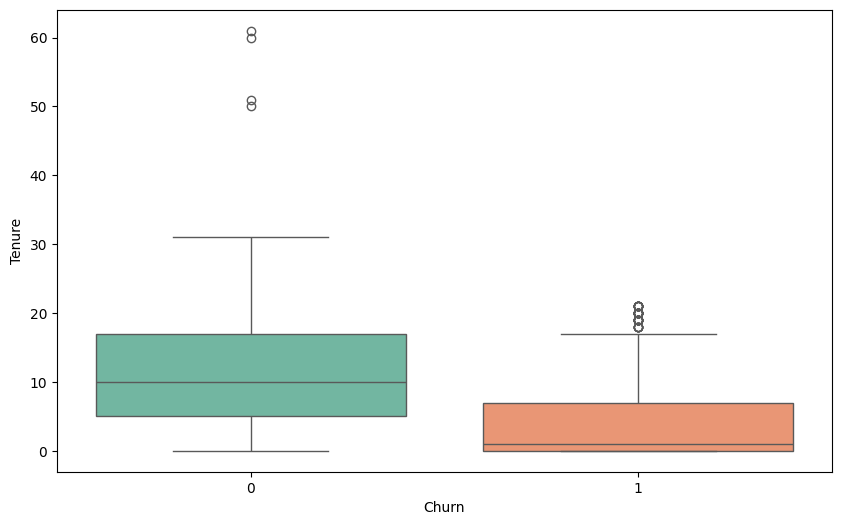

In [20]:
#tenure vs churn
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_churn, x='Churn', y='Tenure', palette="Set2")

**Pelanggan churn cenderung memiliki tenure yang rendah**, artinya mereka adalah pengguna baru yang cepat meninggalkan layanan. Sebaliknya, pelanggan dengan tenure lebih lama relatif lebih loyal dan jarang churn. Hal ini menekankan pentingnya strategi retensi di fase awal perjalanan pelanggan.

In [21]:
df_churn.groupby('Churn')['Tenure'].agg(['mean','median','count'])

,mean,median,count
Churn,,,
0,11.404528,10.0,4682
1,3.859705,1.0,948


In [22]:
from scipy.stats import ttest_ind

churn_group = df_churn[df_churn['Churn']==1]['Tenure']
not_churn_group = df_churn[df_churn['Churn']==0]['Tenure']

t_stat, p = ttest_ind(churn_group, not_churn_group, equal_var=False)
print(f"Mean churn={churn_group.mean():.2f}, mean not churn={not_churn_group.mean():.2f}, p-value={p:.4f}")
if p < 0.05:
    print("Tolak H0. ada perbedaan signifikan antara tenure churn dan not churn")
else:
    print("Gagal Tolak H0. tidak ada perbedaan signifikan antara tenure churn dan not churn")

Mean churn=3.86, mean not churn=11.40, p-value=0.0000
Tolak H0. ada perbedaan signifikan antara tenure churn dan not churn


## HourSpendOnApp vs Churn

/tmp/ipython-input-1488057423.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn, x="Churn", y="HourSpendOnApp", palette="Set2")


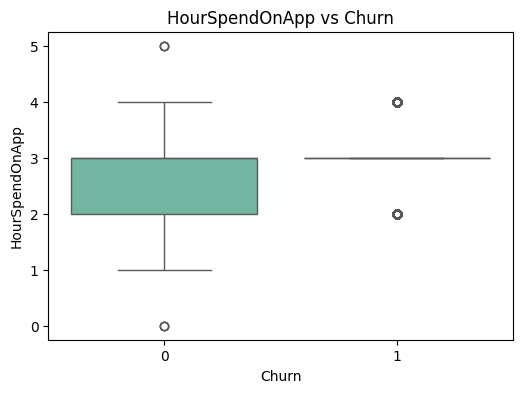

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_churn, x="Churn", y="HourSpendOnApp", palette="Set2")
plt.title("HourSpendOnApp vs Churn")
plt.show()

**Penggunaan aplikasi (HourSpendOnApp) tidak menunjukkan perbedaan signifikan antara churn dan non-churn**. Baik pelanggan churn maupun yang bertahan memiliki pola penggunaan aplikasi yang mirip, sehingga faktor ini bukan indikator utama churn.

## OrderCount vs Churn

/tmp/ipython-input-1910364433.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn, x="Churn", y="OrderCount", palette="Set2")


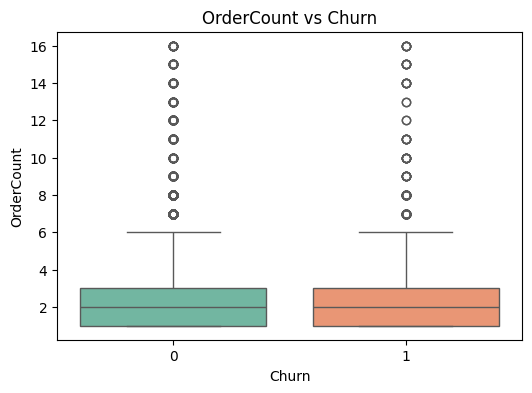

In [24]:
# OrderCount vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(data=df_churn, x="Churn", y="OrderCount", palette="Set2")
plt.title("OrderCount vs Churn")
plt.show()

**OrderCount tidak menunjukkan perbedaan yang berarti antara pelanggan churn dan non-churn.** Baik pelanggan yang bertahan maupun yang churn rata-rata memiliki jumlah order yang serupa, sehingga variabel ini kurang kuat sebagai prediktor churn

## CashbackAmount vs Churn

/tmp/ipython-input-1440757786.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn, x="Churn", y="CashbackAmount", palette="Set2")


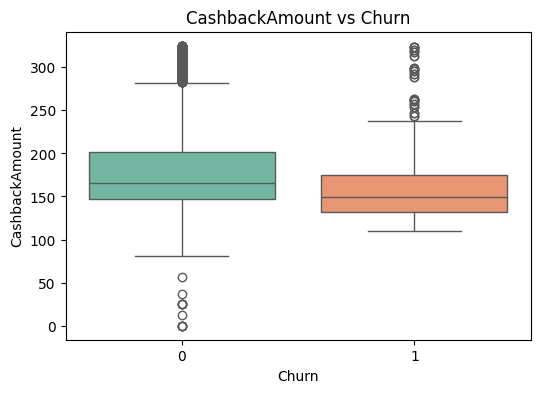

In [25]:

plt.figure(figsize=(6,4))
sns.boxplot(data=df_churn, x="Churn", y="CashbackAmount", palette="Set2")
plt.title("CashbackAmount vs Churn")
plt.show()

**Cashback** terbukti berhubungan dengan loyalitas. Pelanggan yang churn rata-rata mendapat cashback lebih kecil dibanding pelanggan yang bertahan. Hal ini mengindikasikan bahwa pemberian cashback dapat membantu mengurangi churn.

## OrderAmountHikeFromlastYear vs Churn

/tmp/ipython-input-873748161.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn, x="Churn", y="OrderAmountHikeFromlastYear", palette="Set2")


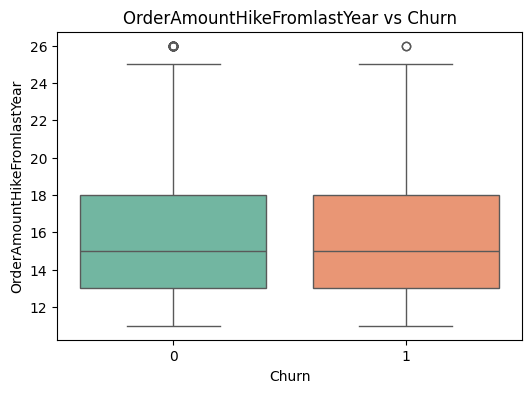

In [26]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_churn, x="Churn", y="OrderAmountHikeFromlastYear", palette="Set2")
plt.title("OrderAmountHikeFromlastYear vs Churn")
plt.show()

**OrderAmountHikeFromlastYear tidak memberikan perbedaan signifikan antara churn dan non-churn.**

Artinya, peningkatan jumlah order dibanding tahun sebelumnya bukan faktor utama yang membedakan siapa yang churn dan siapa yang bertahan.

/tmp/ipython-input-1829856697.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn, x="Churn", y="SatisfactionScore", palette="Set2")


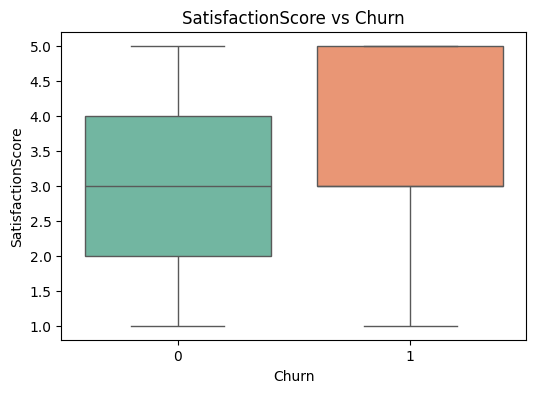

In [27]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_churn, x="Churn", y="SatisfactionScore", palette="Set2")
plt.title("SatisfactionScore vs Churn")
plt.show()

Menariknya, pelanggan dengan satisfaction score tinggi justru menunjukkan churn rate yang lebih tinggi. Hal ini mengindikasikan bahwa kepuasan tidak otomatis menjamin loyalitas. Faktor eksternal seperti metode pembayaran, promo, harga, dan lokasi (CityTier) kemungkinan lebih mempengaruhi keputusan churn dibanding satisfaction score itu sendiri

## Complain vs Churn

/tmp/ipython-input-1007656642.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn, x="Churn", y="Complain", palette="Set2")


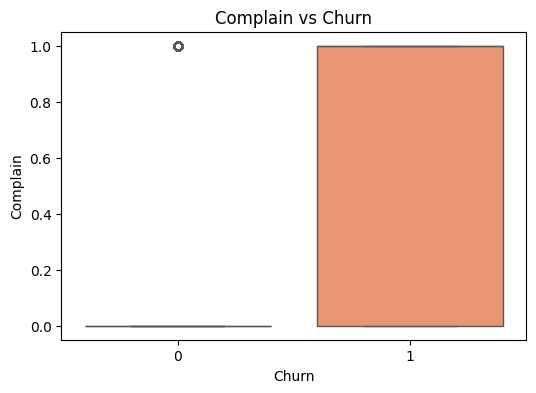

In [28]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_churn, x="Churn", y="Complain", palette="Set2")
plt.title("Complain vs Churn")
plt.show()

Mayoritas pelanggan churn berasal dari kelompok yang pernah melakukan komplain. Sementara pelanggan yang tidak pernah komplain cenderung bertahan. Hal ini menegaskan bahwa komplain adalah salah satu indikator kuat churn

## CouponUsed vs Churn

/tmp/ipython-input-3032043921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn, x="Churn", y="CouponUsed", palette="Set2")


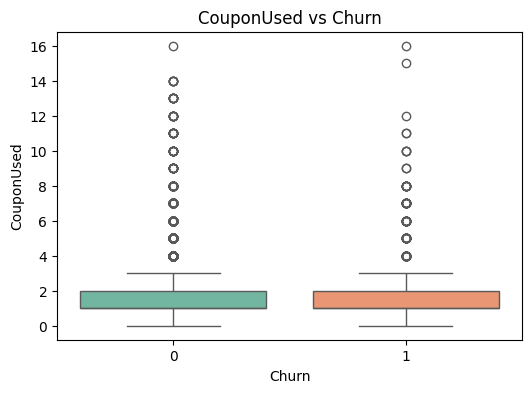

In [29]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_churn, x="Churn", y="CouponUsed", palette="Set2")
plt.title("CouponUsed vs Churn")
plt.show()

Penggunaan kupon tidak menunjukkan perbedaan yang signifikan antara pelanggan churn dan non-churn. Baik yang churn maupun yang bertahan rata-rata menggunakan kupon dalam jumlah yang serupa, sehingga faktor ini bukan indikator utama churn.

## Number of address vs Churn

/tmp/ipython-input-2532380387.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_churn, x="Churn", y="NumberOfAddress", palette="Set2")


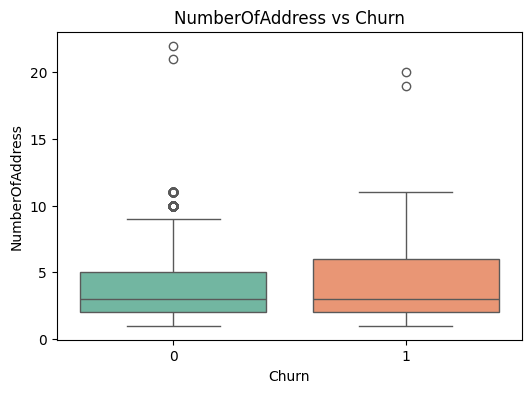

In [30]:
## Number of address vs Churn
plt.figure(figsize=(6,4))
sns.boxplot(data=df_churn, x="Churn", y="NumberOfAddress", palette="Set2")
plt.title("NumberOfAddress vs Churn")
plt.show()

Jumlah alamat yang terdaftar (NumberOfAddress) tidak menunjukkan perbedaan yang signifikan antara pelanggan churn dan non-churn. Baik pelanggan churn maupun yang bertahan rata-rata memiliki jumlah alamat yang serupa, sehingga faktor ini tidak dapat dijadikan indikator utama churn.

## Gender vs Churn

In [31]:
df_churn.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

/tmp/ipython-input-1729860509.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x="Gender", y="Churn", palette="Set2")


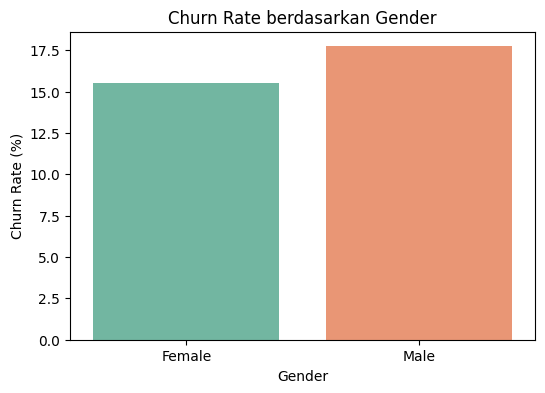

In [32]:
# Gender vs Churn
plt.figure(figsize=(6,4))
churn_rate = (df_churn.groupby("Gender")["Churn"].mean()*100).reset_index()
sns.barplot(data=churn_rate, x="Gender", y="Churn", palette="Set2")
plt.title("Churn Rate berdasarkan Gender")
plt.ylabel("Churn Rate (%)")
plt.show()

Gender Male lebih banyak churn  dibanding Female

## Marital Status vs Churn

proporsi churn not churn berdasarkan marital status

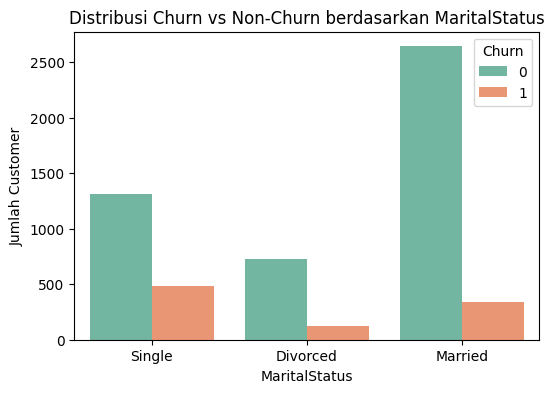

In [33]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_churn, x="MaritalStatus", hue="Churn", palette="Set2")
plt.title("Distribusi Churn vs Non-Churn berdasarkan MaritalStatus")
plt.ylabel("Jumlah Customer")
plt.show()

dari segi proporsi yang churn mayoritas dari status single sekitar 1200 lebih

presentase marital status vs churn

/tmp/ipython-input-501730295.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x="MaritalStatus", y="Churn", palette="Set2")


Text(0, 0.5, 'Churn Rate (%)')

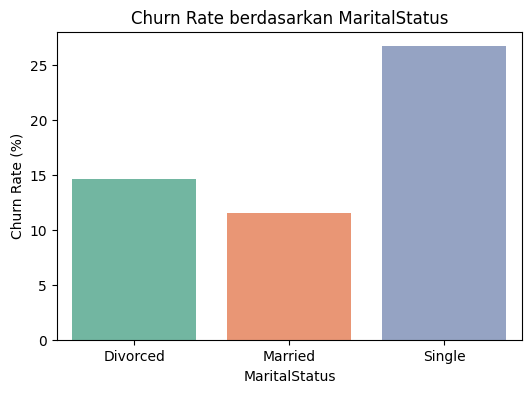

In [34]:
# MaritalStatus vs Churn
plt.figure(figsize=(6,4))
churn_rate = (df_churn.groupby("MaritalStatus")["Churn"].mean()*100).reset_index()
sns.barplot(data=churn_rate, x="MaritalStatus", y="Churn", palette="Set2")
plt.title("Churn Rate berdasarkan MaritalStatus")
plt.ylabel("Churn Rate (%)")

churnrate yang paling besar adakah status single dengan presentase 26%, divorced 14% dan married 10%

## CityTier vs Churn

proporsi cityTier vs churn not churn

<Axes: xlabel='CityTier', ylabel='count'>

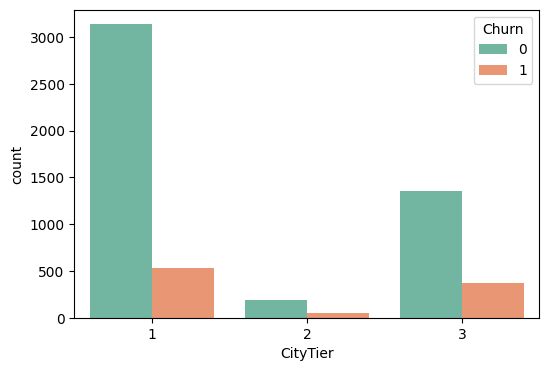

In [35]:
#churn vs city tier
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=df_churn, x='CityTier', hue='Churn', palette="Set2")

/tmp/ipython-input-905326562.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x="CityTier", y="Churn", palette="Set2")


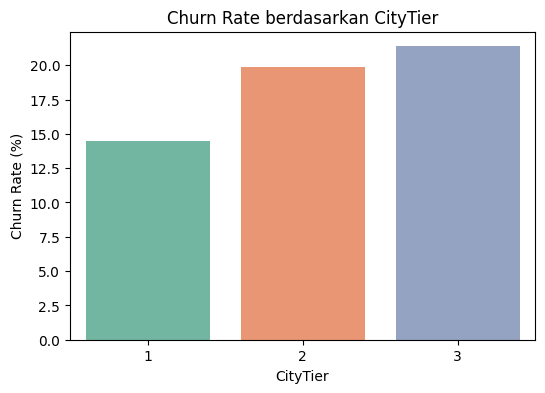

In [36]:
plt.figure(figsize=(6,4))
churn_rate = (df_churn.groupby("CityTier")["Churn"].mean()*100).reset_index()
sns.barplot(data=churn_rate, x="CityTier", y="Churn", palette="Set2")
plt.title("Churn Rate berdasarkan CityTier")
plt.ylabel("Churn Rate (%)")
plt.show()

churnrate berdasarkan CityTier adalah berasal dari cityTier 3, bisa saja karena keterbatasan akomodasi atau akses atau adanya gap layanan antara kota besar dan kota kecil. Pelanggan di kota kecil mungkin lebih sensitif terhadap kualitas layanan atau harga, sehingga lebih rentan berpindah ke kompetitor.

## paymentmode vs Churn




In [37]:
df_churn[["Churn","PreferredPaymentMode"]].value_counts()

Churn  PreferredPaymentMode
0      Debit Card              1958
       Credit Card             1308
       E wallet                 474
       Cash on Delivery         386
1      Debit Card               356
0      UPI                      342
       CC                       214
1      Credit Card              193
       E wallet                 140
       Cash on Delivery         128
       UPI                       72
       CC                        59
Name: count, dtype: int64

/tmp/ipython-input-300802576.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x="PreferredPaymentMode", y="Churn", palette="Set2")


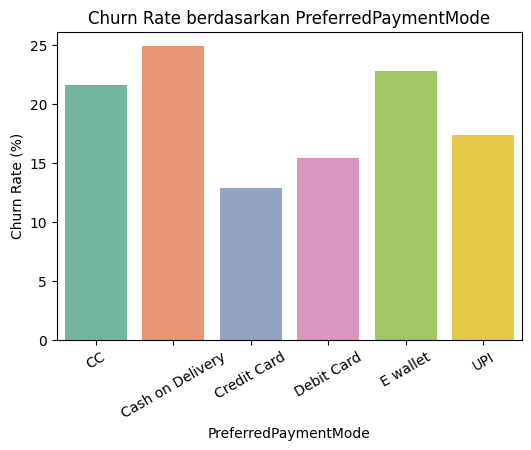

In [38]:
# PreferredPaymentMode vs Churn
plt.figure(figsize=(6,4))
churn_rate = (df_churn.groupby("PreferredPaymentMode")["Churn"].mean()*100).reset_index()
sns.barplot(data=churn_rate, x="PreferredPaymentMode", y="Churn", palette="Set2")
plt.title("Churn Rate berdasarkan PreferredPaymentMode")
plt.xticks(rotation=30)
plt.ylabel("Churn Rate (%)")
plt.show()

Dari sisi metode pembayaran, pelanggan yang menggunakan Cash on Delivery (COD) memiliki churn rate paling tinggi, diikuti oleh pengguna E-Wallet. Ini mengindikasikan bahwa pelanggan COD cenderung kurang loyal, mungkin karena komitmen rendah dan kecenderungan mencoba-coba. Sementara pada pengguna E-Wallet, churn kemungkinan disebabkan oleh sifat mereka yang oportunis terhadap promo atau insentif.

## Prefferordercat vs Churn

<Axes: xlabel='PreferedOrderCat', ylabel='count'>

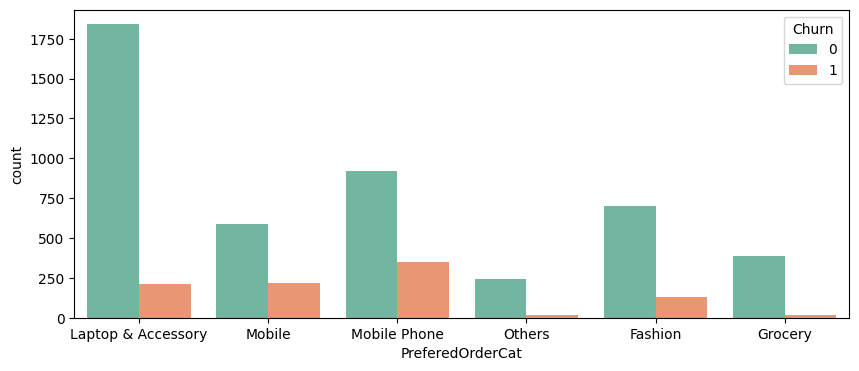

In [39]:
#churn vs preffered ordercat
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
sns.countplot(data=df_churn, x='PreferedOrderCat', hue='Churn', palette="Set2")

/tmp/ipython-input-3687272129.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_rate, x="PreferedOrderCat", y="Churn", palette="Set2")


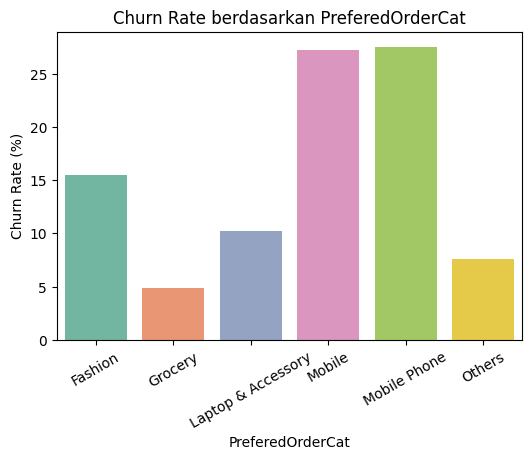

In [40]:
# PreferedOrderCat vs Churn
plt.figure(figsize=(6,4))
churn_rate = (df_churn.groupby("PreferedOrderCat")["Churn"].mean()*100).reset_index()
sns.barplot(data=churn_rate, x="PreferedOrderCat", y="Churn", palette="Set2")
plt.title("Churn Rate berdasarkan PreferedOrderCat")
plt.xticks(rotation=30)
plt.ylabel("Churn Rate (%)")
plt.show()

berdasarkan kategori pembelian ternyata mobile phone yang paling banyak churn, ini bisa jadi karena mereka hanya sekali membeli lalu tidak repeat order. yang minim churn disini adalah grocery

# Uji Statistik

##HourSpendOnApp vs Churn

In [41]:
from scipy.stats import ttest_ind, mannwhitneyu

# Pisahkan data berdasarkan churn
hours_churn0 = df_churn[df_churn['Churn']==0]['HourSpendOnApp']
hours_churn1 = df_churn[df_churn['Churn']==1]['HourSpendOnApp']

# Independent T-test
t_stat, p_val_t = ttest_ind(hours_churn0, hours_churn1, equal_var=False)
print("T-test HourSpendOnApp vs Churn -> t-stat:", round(t_stat,3), " p-value:", p_val_t)

if p_val_t < 0.05:
    print("Tolak H0 → ada perbedaan signifikan antara HourSpendOnApp churn 0 dan 1")
else:
    print("Gagal tolak H0 → tidak ada perbedaan signifikan HourSpendOnApp churn 0 dan 1")

print("\n")

# Mann-Whitney U Test
u_stat, p_val_u = mannwhitneyu(hours_churn0, hours_churn1)
print("Mann-Whitney HourSpendOnApp vs Churn -> U-stat:", u_stat, " p-value:", p_val_u)

if p_val_u < 0.05:
    print("Tolak H0 → ada perbedaan signifikan antara HourSpendOnApp churn 0 dan 1")
else:
    print("Gagal tolak H0 → tidak ada perbedaan signifikan HourSpendOnApp churn 0 dan 1")

T-test HourSpendOnApp vs Churn -> t-stat: -1.466  p-value: 0.14300103213870458
Gagal tolak H0 → tidak ada perbedaan signifikan HourSpendOnApp churn 0 dan 1


Mann-Whitney HourSpendOnApp vs Churn -> U-stat: 2167074.0  p-value: 0.20945943456720229
Gagal tolak H0 → tidak ada perbedaan signifikan HourSpendOnApp churn 0 dan 1


## Couponused vs Churn

In [42]:
from scipy.stats import ttest_ind, mannwhitneyu

# Pisahkan data berdasarkan churn
coupon_churn0 = df_churn[df_churn['Churn']==0]['CouponUsed']
coupon_churn1 = df_churn[df_churn['Churn']==1]['CouponUsed']

# Independent T-test
t_stat, p_val_t = ttest_ind(coupon_churn0, coupon_churn1, equal_var=False)
print("T-test CouponUsed vs Churn -> t-stat:", round(t_stat,3), " p-value:", p_val_t)

if p_val_t < 0.05:
    print("Tolak H0 → ada perbedaan signifikan antara CouponUsed churn 0 dan 1")
else:
    print("Gagal tolak H0 → tidak ada perbedaan signifikan CouponUsed churn 0 dan 1")

print("\n")

# Mann-Whitney U Test
u_stat, p_val_u = mannwhitneyu(coupon_churn0, coupon_churn1)
print("Mann-Whitney CouponUsed vs Churn -> U-stat:", u_stat, " p-value:", p_val_u)

if p_val_u < 0.05:
    print("Tolak H0 → ada perbedaan signifikan antara CouponUsed churn 0 dan 1")
else:
    print("Gagal tolak H0 → tidak ada perbedaan signifikan CouponUsed churn 0 dan 1")

T-test CouponUsed vs Churn -> t-stat: 0.106  p-value: 0.9159384616337447
Gagal tolak H0 → tidak ada perbedaan signifikan CouponUsed churn 0 dan 1


Mann-Whitney CouponUsed vs Churn -> U-stat: 2245721.5  p-value: 0.5430023781861197
Gagal tolak H0 → tidak ada perbedaan signifikan CouponUsed churn 0 dan 1


## Order Count vs Churn

In [43]:
from scipy.stats import ttest_ind, mannwhitneyu

# Pisahkan data berdasarkan churn
order_churn0 = df_churn[df_churn['Churn']==0]['OrderCount']
order_churn1 = df_churn[df_churn['Churn']==1]['OrderCount']

# Independent T-test
t_stat, p_val_t = ttest_ind(order_churn0, order_churn1, equal_var=False)
print("T-test OrderCount vs Churn -> t-stat:", round(t_stat,3), " p-value:", p_val_t)

if p_val_t < 0.05:
    print("Tolak H0 → ada perbedaan signifikan antara OrderCount churn 0 dan 1")
else:
    print("Gagal tolak H0 → tidak ada perbedaan signifikan OrderCount churn 0 dan 1")

print("\n")

# Mann-Whitney U Test
u_stat, p_val_u = mannwhitneyu(order_churn0, order_churn1)
print("Mann-Whitney OrderCount vs Churn -> U-stat:", u_stat, " p-value:", p_val_u)

if p_val_u < 0.05:
    print("Tolak H0 → ada perbedaan signifikan antara OrderCount churn 0 dan 1")
else:
    print("Gagal tolak H0 → tidak ada perbedaan signifikan OrderCount churn 0 dan 1")


T-test OrderCount vs Churn -> t-stat: 1.852  p-value: 0.06430615371620459
Gagal tolak H0 → tidak ada perbedaan signifikan OrderCount churn 0 dan 1


Mann-Whitney OrderCount vs Churn -> U-stat: 2313084.0  p-value: 0.03050037481644772
Tolak H0 → ada perbedaan signifikan antara OrderCount churn 0 dan 1


Hasil uji statistik untuk OrderCount berbeda antara T-test dan Mann-Whitney. Karena distribusi OrderCount tidak normal, Mann-Whitney lebih tepat digunakan. Dengan p-value < 0.05, OrderCount memiliki perbedaan signifikan antara churn dan non-churn, meskipun kontribusinya relatif kecil.

## NumberofAddres vs Churn

In [44]:
from scipy.stats import ttest_ind, mannwhitneyu

# Pisahkan data berdasarkan churn
addr_churn0 = df_churn[df_churn['Churn']==0]['NumberOfAddress']
addr_churn1 = df_churn[df_churn['Churn']==1]['NumberOfAddress']

# Independent T-test
t_stat, p_val_t = ttest_ind(addr_churn0, addr_churn1, equal_var=False)
print("T-test NumberOfAddress vs Churn -> t-stat:", round(t_stat,3), " p-value:", p_val_t)

if p_val_t < 0.05:
    print("Tolak H0 → ada perbedaan signifikan antara NumberOfAddress churn 0 dan 1")
else:
    print("Gagal tolak H0 → tidak ada perbedaan signifikan NumberOfAddress churn 0 dan 1")

print("\n")

# Mann-Whitney U Test
u_stat, p_val_u = mannwhitneyu(addr_churn0, addr_churn1)
print("Mann-Whitney NumberOfAddress vs Churn -> U-stat:", u_stat, " p-value:", p_val_u)

if p_val_u < 0.05:
    print("Tolak H0 → ada perbedaan signifikan antara NumberOfAddress churn 0 dan 1")
else:
    print("Gagal tolak H0 → tidak ada perbedaan signifikan NumberOfAddress churn 0 dan 1")


T-test NumberOfAddress vs Churn -> t-stat: -3.098  p-value: 0.0019934997986827364
Tolak H0 → ada perbedaan signifikan antara NumberOfAddress churn 0 dan 1


Mann-Whitney NumberOfAddress vs Churn -> U-stat: 2121979.5  p-value: 0.03049724563723119
Tolak H0 → ada perbedaan signifikan antara NumberOfAddress churn 0 dan 1


Number of Address terbukti signifikan dalam memengaruhi churn. Pelanggan yang churn cenderung memiliki alamat lebih sedikit dibandingkan pelanggan non-churn. Hal ini mengindikasikan bahwa semakin banyak alamat yang terdaftar (misalnya rumah, kantor), semakin tinggi tingkat keterikatan pelanggan, sehingga lebih loyal.

##tenure vs churn

In [45]:
#uji statistik tenure vs churn
from scipy.stats import ttest_ind

#t-test
churn_group = df_churn[df_churn['Churn']==1]['Tenure']
not_churn_group = df_churn[df_churn['Churn']==0]['Tenure']

t_stat, p = ttest_ind(churn_group, not_churn_group, equal_var=False)

print(f"T-Test : Mean churn={churn_group.mean():.2f}, mean not churn={not_churn_group.mean():.2f}, p-value={p:.4f}")

if p < 0.05:
    print("Tolak H0. ada perbedaan signifikan antara tenure churn dan not churn")
else:
    print("Gagal Tolak H0. tidak ada perbedaan signifikan antara tenure churn dan not churn")
print("\n")
#Mann-Whitney
from scipy.stats import mannwhitneyu

#Uji Mann-Whitney
stat, p = mannwhitneyu(churn_group, not_churn_group)
print(f"Mann-Whitney : stat={stat:.2f}, p-value={p:.4f}")
if p < 0.05:
    print("Tolak H0. ada perbedaan signifikan antara tenure churn dan not churn")
else:
    print("Gagal Tolak H0. tidak ada perbedaan signifikan antara tenure churn dan not churn")

T-Test : Mean churn=3.86, mean not churn=11.40, p-value=0.0000
Tolak H0. ada perbedaan signifikan antara tenure churn dan not churn


Mann-Whitney : stat=910384.00, p-value=0.0000
Tolak H0. ada perbedaan signifikan antara tenure churn dan not churn


## Cashback vs Churn

In [46]:
from scipy.stats import ttest_ind, mannwhitneyu

# Pisahkan data CashbackAmount berdasarkan churn
cashback_churn0 = df_churn[df_churn['Churn']==0]['CashbackAmount']
cashback_churn1 = df_churn[df_churn['Churn']==1]['CashbackAmount']

# Independent T-test
t_stat, p_val_t = ttest_ind(cashback_churn0, cashback_churn1, equal_var=False)
print("T-test CashbackAmount vs Churn -> t-stat:", t_stat, " p-value:", p_val_t)

if p_val_t < 0.05:
    print("Tolak H0. ada perbedaan signifikan antara cashback churn 0 dan 1")
else:
    print("Gagal Tolak H0. tidak ada perbedaan signifikan antara cashback churn 0 dan 1")
print("\n")
# Mann-Whitney U Test
u_stat, p_val_u = mannwhitneyu(cashback_churn0, cashback_churn1)
print(f"Mann-Whitney : stat={stat:.2f}, p-value={p:.4f}")
if p < 0.05:
    print("Tolak H0. ada perbedaan signifikan antara tenure churn dan not churn")
else:
    print("Gagal Tolak H0. tidak ada perbedaan signifikan antara tenure churn dan not churn")

T-test CashbackAmount vs Churn -> t-stat: 13.978181093361261  p-value: 4.3622347482862773e-42
Tolak H0. ada perbedaan signifikan antara cashback churn 0 dan 1


Mann-Whitney : stat=910384.00, p-value=0.0000
Tolak H0. ada perbedaan signifikan antara tenure churn dan not churn


##CityTier vs Churn

In [47]:
import scipy.stats as stats
import pandas as pd

ct_table = pd.crosstab(df_churn['CityTier'], df_churn['Churn'])
chi2, p, dof, expected = stats.chi2_contingency(ct_table)
print("Chi-Square CityTier vs Churn -> chi2:", chi2, " p-value:", p)

if p < 0.05:
    print("Tolak H0. ada perbedaan signifikan antara CityTier dan Churn")
else:
    print("Gagal Tolak H0. tidak ada perbedaan signifikan antara CityTier dan Churn")

Chi-Square CityTier vs Churn -> chi2: 40.982404247736355  p-value: 1.2612000812079956e-09
Tolak H0. ada perbedaan signifikan antara CityTier dan Churn


##PreferredPaymentMode vs Churn

In [48]:
pm_table = pd.crosstab(df_churn['PreferredPaymentMode'], df_churn['Churn'])
chi2, p, dof, expected = stats.chi2_contingency(pm_table)
print("Chi-Square PaymentMode vs Churn -> chi2:", chi2, " p-value:", p)
if p < 0.05:
    print("Tolak H0. ada perbedaan signifikan antara PaymentMode dan Churn")
else:
    print("Gagal Tolak H0. tidak ada perbedaan signifikan antara PaymentMode dan Churn")

Chi-Square PaymentMode vs Churn -> chi2: 64.4688365646396  p-value: 1.444315094282301e-12
Tolak H0. ada perbedaan signifikan antara PaymentMode dan Churn


##Complain vs Churn

In [49]:
complain_table = pd.crosstab(df_churn['Complain'], df_churn['Churn'])
chi2, p, dof, expected = stats.chi2_contingency(complain_table)
print("Chi-Square Complain vs Churn -> chi2:", chi2, " p-value:", p)
if p < 0.05:
    print("Tolak H0. ada perbedaan signifikan antara Complain dan Churn")
else:
    print("Gagal Tolak H0. tidak ada perbedaan signifikan antara Complain dan Churn")

Chi-Square Complain vs Churn -> chi2: 350.92545525927073  p-value: 2.6644609654641377e-78
Tolak H0. ada perbedaan signifikan antara Complain dan Churn


Dari hasil uji statistik, variabel yang berpengaruh signifikan terhadap churn adalah **Tenure, CashbackAmount, CityTier, PreferredPaymentMode, dan Complain**. Variabel lain seperti HourSpendOnApp, CouponUsed, OrderCount, NumberOfAddress, dan SatisfactionScore tidak signifikan atau hasilnya tidak konsisten. Hal ini menegaskan bahwa churn lebih dipengaruhi oleh faktor lama bergabung, insentif cashback, lokasi pelanggan, metode pembayaran, serta pengalaman komplain, dibanding aktivitas sehari-hari seperti jumlah order, kupon, atau jam penggunaan aplikasi.

#Kesimpulan
Churn terutama dipengaruhi oleh faktor **Tenure, Cashback, CityTier, PaymentMode, dan Complain.** Pelanggan baru, tinggal di kota kecil, menggunakan COD/E-Wallet, jarang mendapat cashback, dan pernah komplain adalah segmen paling rentan churn. Faktor tambahan seperti jumlah order dan jumlah alamat juga memberi sinyal churn meski pengaruhnya lebih kecil. Sementara itu, jam **penggunaan aplikasi, penggunaan kupon, dan satisfaction score tidak berhubungan signifikan dengan churn**

| **Area**               | **Ringkasan**                                                                                    | **Dampak**                                          |
| ---------------------- | ------------------------------------------------------------------------------------------------ | --------------------------------------------------- |
| **Segmen Rentan**      | Churn tinggi: pelanggan baru, CityTier 3, COD/E-Wallet, jarang cashback, pernah komplain         | Fokus retensi ke segmen ini → biaya lebih efisien   |
| **Layanan**            | **Complain** signifikan → perlu peningkatan kualitas & respon cepat                              | Kepuasan naik, churn turun, pendapatan terjaga      |
| **Cashback & Payment** | **Cashback** menahan pelanggan, COD/E-Wallet lebih rentan churn                                  | Loyalty & insentif pembayaran lebih tepat sasaran   |
| **Revenue Impact**     | Churn 16,8% → potensi hilang ± **Rp474 jt/bln** <br> Retensi 5% → selamatkan ± **Rp23,5 jt/bln** | Dampak finansial konkret → analisis bernilai bisnis |


#Rekomendasi Bisnis

| **Area Fokus**                   | **Aksi yang Disarankan**                                                                                           | **Tujuan**                                                                               |
| -------------------------------- | ------------------------------------------------------------------------------------------------------------------ | ---------------------------------------------------------------------------------------- |
| **Onboarding & Early Retention** | - Program welcome (voucher, tutorial, reminder notifikasi) <br> - Edukasi penggunaan aplikasi untuk pelanggan baru | Mengurangi churn di bulan-bulan awal dan meningkatkan keterikatan pelanggan              |
| **CityTier 3 (Kota Kecil)**      | - Perbaikan kualitas & kecepatan logistik <br> - Kerja sama dengan mitra lokal untuk distribusi                    | Meningkatkan pengalaman pelanggan di area dengan churn tertinggi                         |
| **Cashback & Loyalty Program**   | - Distribusi cashback lebih merata <br> - Tambah reward/point system agar pelanggan lebih engaged                  | Meningkatkan loyalitas & mengurangi churn pada pelanggan yang jarang menerima cashback   |
| **Metode Pembayaran**            | - Beri insentif untuk non-COD (diskon kecil untuk transfer/kartu) <br> - Edukasi manfaat pembayaran digital        | Mengurangi churn dari pelanggan COD/E-Wallet dan mengalihkan ke metode yang lebih stabil |
| **Handling Komplain**            | - Tambah kanal komunikasi (chatbot, live chat) <br> - Terapkan SLA penanganan cepat                                | Meningkatkan kepuasan pelanggan & menurunkan churn akibat komplain                       |
| **Monitoring & Evaluasi**        | - Bangun dashboard churn tracking <br> - Lakukan A/B testing strategi retensi                                      | Mengukur efektivitas strategi retensi & memastikan keputusan berbasis data               |
